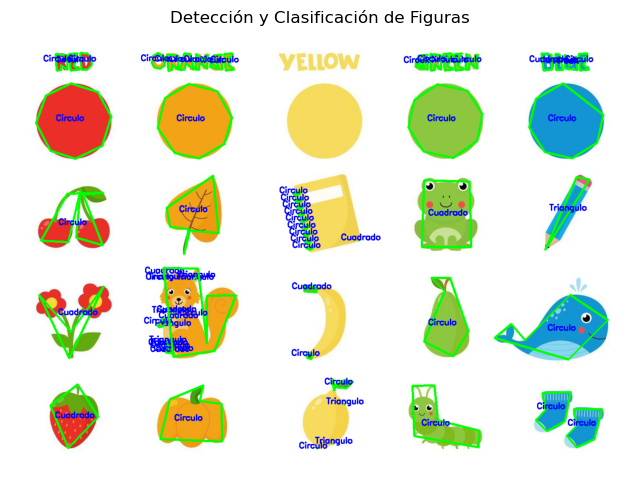

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = 'colores.jpg'
image = cv2.imread(image_path)
output_image = image.copy()

# Pasar a grises y binarizar para que findContours detecte las figuras
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

for cnt in contours:
    M = cv2.moments(cnt)
    if M['m00'] == 0:
        continue
    # Calcular Momentos de Hu
    huMoments = cv2.HuMoments(M)
    # Calcular el centro de la figura para ubicar el texto
    cx = int(M['m10'] / M['m00'])
    cy = int(M['m01'] / M['m00'])
    # Aproximación del contorno (margen de error del 4%)
    epsilon = 0.04 * cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, epsilon, True)
    vertices = len(approx)
    # Clasificar la figura por cantidad de vértices
    if vertices == 3:
        shape_name = "Triangulo"
    elif vertices == 4:
        shape_name = "Cuadrado"
    else:
        shape_name = "Circulo"

    cv2.drawContours(output_image, [approx], 0, (0, 255, 0), 3)
    cv2.putText(output_image, shape_name, (cx - 40, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
# Mostrar el resultado final en el Notebook
output_image_rgb = cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(output_image_rgb)
plt.axis('off')
plt.title('Detección y Clasificación de Figuras')
plt.show()